In [1]:
import torch
import torchvision
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import json
from tqdm import tqdm
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import random
from collections import defaultdict
from scipy import ndimage
import time
from sklearn.metrics import roc_curve, auc, f1_score

In [2]:
# =========================================================
# DATASET PATHS
# =========================================================

PRUNED_PATH       = "/kaggle/input/datasets/harshitabansal307/deepfashion-pruned-dataset"
SEG_PATH          = "/kaggle/input/datasets/harshitabansal307/task2-preprocessed-detetcion-segmentation/preprocessed"

train_pt          = os.path.join(SEG_PATH, "train_detection_samples_balanced.pt")
val_pt            = os.path.join(SEG_PATH, "val_detection_samples_balanced.pt")
category_map_path = os.path.join(SEG_PATH, "category_map.pt")
weights_pt        = os.path.join(SEG_PATH, "class_weights.pt")

In [3]:
train_data    = torch.load(train_pt)
val_data      = torch.load(val_pt)
class_weights = torch.load(weights_pt)

print("Train:", len(train_data))
print("Val:",   len(val_data))
print(train_data[0].keys())

Train: 20000
Val: 5000
dict_keys(['img_path', 'boxes', 'labels', 'polygons'])


In [4]:
# =========================================================
# CATEGORY MAP
# New preprocessing: labels are 1-5, background=0
# category_map: {1:1, 8:2, 7:3, 2:4, 9:5}
# =========================================================

category_map = torch.load(category_map_path)
NUM_CLASSES  = len(category_map)   # 5

CLASS_NAMES = [
    "__background__",
    "short sleeve top",
    "trousers",
    "shorts",
    "long sleeve top",
    "skirt"
]

print("category_map:", category_map)
print("NUM_CLASSES:", NUM_CLASSES)

label_map = {
    "short sleeve top": 1,
    "trousers":         2,
    "shorts":           3,
    "long sleeve top":  4,
    "skirt":            5
}

with open("/kaggle/working/label_map.json", "w") as f:
    json.dump(label_map, f, indent=4)

print("label_map.json saved")
print("Class weights:", class_weights)

category_map: {1: 1, 8: 2, 7: 3, 2: 4, 9: 5}
NUM_CLASSES: 5
label_map.json saved
Class weights: tensor([0.0217, 0.6984, 0.9034, 1.3665, 1.3874, 1.6227])


In [5]:
# =========================================================
# POLYGON -> MASK
# Labels are already 1-5 from new preprocessing — use directly
# =========================================================

def polygons_to_mask(polygons, labels, h, w):

    mask = np.zeros((h, w), dtype=np.uint8)

    for poly_set, label in zip(polygons, labels):

        if int(label) not in category_map:
            continue

        for poly in poly_set:
            poly = np.array(poly, dtype=np.int32).reshape(-1, 2)
            cv2.fillPoly(mask, [poly], int(label))   # labels already 1-5

    return mask

In [6]:
class DeepFashionDataset(Dataset):

    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        sample = self.data[idx]

        img = cv2.imread(sample["img_path"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        h, w, _ = img.shape

        mask = polygons_to_mask(sample["polygons"], sample["labels"], h, w)

        # augmentation
        if random.random() > 0.5:
            img  = np.fliplr(img).copy()
            mask = np.fliplr(mask).copy()

        img  = cv2.resize(img,  (256, 256))
        mask = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)

        img  = torch.tensor(img).permute(2, 0, 1).float() / 255
        mask = torch.tensor(mask).long()

        return img, mask

In [7]:
train_dataset = DeepFashionDataset(train_data)
val_dataset   = DeepFashionDataset(val_data)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

In [8]:
class DoubleConv(nn.Module):

    def __init__(self, in_c, out_c):

        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.net(x)

In [9]:
class UNet(nn.Module):

    def __init__(self, n_classes):

        super().__init__()

        self.enc1 = DoubleConv(3,   64)
        self.enc2 = DoubleConv(64,  128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(512, 1024)

        self.up4  = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = DoubleConv(1024, 512)

        self.up3  = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = DoubleConv(512, 256)

        self.up2  = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(256, 128)

        self.up1  = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, n_classes + 1, 1)

    def forward(self, x):

        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out(d1)

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [11]:
def dice_loss(pred, target, smooth=1e-5):

    pred          = torch.softmax(pred, dim=1)
    target_onehot = torch.nn.functional.one_hot(target, NUM_CLASSES + 1)
    target_onehot = target_onehot.permute(0, 3, 1, 2).float()

    intersection = (pred * target_onehot).sum(dim=(2, 3))
    union        = pred.sum(dim=(2, 3)) + target_onehot.sum(dim=(2, 3))

    dice = (2 * intersection + smooth) / (union + smooth)

    return 1 - dice.mean()

In [12]:
training_times = {}

def train_model(model, name, epochs=8):

    start = time.time()

    model     = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    # Weighted CE loss — handles class imbalance
    ce_loss   = nn.CrossEntropyLoss(weight=class_weights.to(device))

    losses = []

    for epoch in range(epochs):

        model.train()
        total_loss = 0

        for imgs, masks in tqdm(train_loader):

            imgs  = imgs.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()

            outputs = model(imgs)

            loss = ce_loss(outputs, masks) + dice_loss(outputs, masks)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        epoch_loss = total_loss / len(train_loader)
        losses.append(epoch_loss)

        print(name, "Epoch", epoch + 1, "Loss", epoch_loss)

    end = time.time()

    training_times[name] = end - start

    torch.save(model.state_dict(), f"/kaggle/working/{name}.pth")

    plt.figure()
    plt.plot(losses)
    plt.title(name + " Loss")
    plt.savefig(f"/kaggle/working/{name}_loss.png")

    return model

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 204MB/s]
100%|██████████| 2500/2500 [21:27<00:00,  1.94it/s]


Transfer Epoch 1 Loss 1.71114731092453


100%|██████████| 2500/2500 [21:35<00:00,  1.93it/s]


Transfer Epoch 2 Loss 1.3927043962955474


...

Transfer Epoch 6 Loss 1.166425562787056


100%|██████████| 2500/2500 [21:39<00:00,  1.92it/s]


Transfer Epoch 7 Loss 1.1355191385269165


100%|██████████| 2500/2500 [21:39<00:00,  1.92it/s]


Transfer Epoch 8 Loss 0.6674700063347816


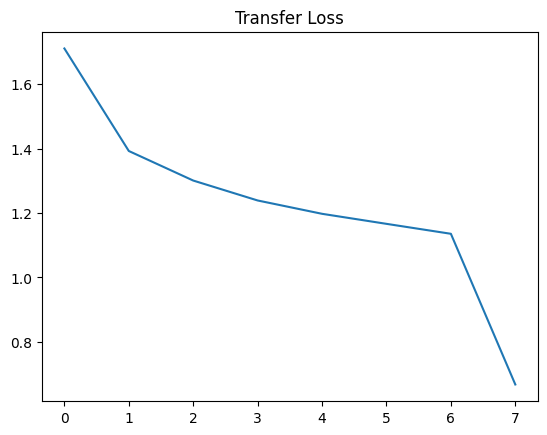

In [13]:
# =========================================================
# TRANSFER LEARNING
# Load ResNet34 pretrained conv1 weights into enc1
# =========================================================

encoder = torchvision.models.resnet34(
    weights=torchvision.models.ResNet34_Weights.DEFAULT
)

model_transfer = UNet(NUM_CLASSES)

# use pretrained conv
pretrained_conv        = encoder.conv1
# fix stride
pretrained_conv.stride = (1, 1)

model_transfer.enc1.net[0] = pretrained_conv

model_transfer = train_model(model_transfer, "Transfer", epochs=8)

100%|██████████| 2500/2500 [19:47<00:00,  2.11it/s]


Finetune Epoch 1 Loss 1.6837350486755371


100%|██████████| 2500/2500 [19:47<00:00,  2.11it/s]


Finetune Epoch 2 Loss 1.3996236819505692


100%|██████████| 2500/2500 [19:48<00:00,  2.10it/s]


...

Finetune Epoch 6 Loss 1.1848058420181273


100%|██████████| 2500/2500 [19:48<00:00,  2.10it/s]


Finetune Epoch 7 Loss 1.1562899760723113


100%|██████████| 2500/2500 [19:49<00:00,  2.10it/s]


Finetune Epoch 8 Loss 0.727571712732315


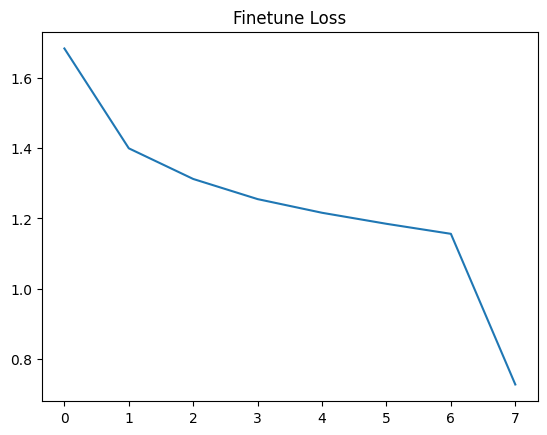

In [14]:
# =========================================================
# FINE-TUNING
# Start from Transfer weights, freeze enc1
# =========================================================

model_finetune = UNet(NUM_CLASSES)

for param in model_finetune.enc1.parameters():
    param.requires_grad = False

model_finetune = train_model(model_finetune, "Finetune", epochs=8)

In [15]:
# =========================================================
# METRICS — per-class IoU + Dice (segmentation)
# =========================================================

def compute_iou(pred, gt):
    intersection = np.logical_and(pred, gt).sum()
    union        = np.logical_or(pred, gt).sum()
    if union == 0:
        return 0
    return intersection / union


def dice_score(pred, gt):
    intersection = (pred * gt).sum()
    return (2 * intersection) / ((pred.sum() + gt.sum()) + 1e-8)


def compute_per_class_seg_metrics(all_preds, all_masks, num_classes):
    iou_per_class  = []
    dice_per_class = []

    for cls in range(1, num_classes + 1):
        pred_cls = (all_preds == cls)
        mask_cls = (all_masks == cls)

        intersection = np.logical_and(pred_cls, mask_cls).sum()
        union        = np.logical_or(pred_cls,  mask_cls).sum()

        iou  = np.nan if union == 0 else intersection / union

        denom = pred_cls.sum() + mask_cls.sum()
        dice  = np.nan if denom == 0 else (2 * intersection) / denom

        iou_per_class.append(iou)
        dice_per_class.append(dice)

    return np.array(iou_per_class), np.array(dice_per_class)

In [16]:
# =========================================================
# DETECTION METRICS — mAP, ROC, AUC, F1
# =========================================================

def bbox_iou(b1, b2):
    ix1 = max(b1[0], b2[0]); iy1 = max(b1[1], b2[1])
    ix2 = min(b1[2], b2[2]); iy2 = min(b1[3], b2[3])
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    a1    = (b1[2]-b1[0]) * (b1[3]-b1[1])
    a2    = (b2[2]-b2[0]) * (b2[3]-b2[1])
    union = a1 + a2 - inter
    return inter / union if union > 0 else 0


def extract_pred_boxes(mask, num_classes, min_area=50):
    boxes, labels, scores = [], [], []
    for cls in range(1, num_classes + 1):
        binary       = (mask == cls).astype(np.uint8)
        labeled, num = ndimage.label(binary)
        for i in range(1, num + 1):
            region = (labeled == i)
            area   = region.sum()
            if area < min_area:
                continue
            ys, xs = np.where(region)
            boxes.append([int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())])
            labels.append(cls)
            scores.append(float(area) / (256 * 256))
    return boxes, labels, scores


def compute_detection_metrics(all_preds, val_data_subset, num_classes,
                               iou_thresholds=None, img_size=256):
    if iou_thresholds is None:
        iou_thresholds = np.arange(0.5, 1.0, 0.05)

    class_tp  = {c: [] for c in range(1, num_classes + 1)}
    class_fp  = {c: [] for c in range(1, num_classes + 1)}
    class_sc  = {c: [] for c in range(1, num_classes + 1)}
    class_ngt = {c: 0  for c in range(1, num_classes + 1)}

    gt_presence   = {c: [] for c in range(1, num_classes + 1)}
    pred_presence = {c: [] for c in range(1, num_classes + 1)}

    for pred_mask, sample in zip(all_preds, val_data_subset):

        gt_boxes  = sample["boxes"]
        gt_labels = sample["labels"]

        img = cv2.imread(sample["img_path"])
        if img is None:
            continue
        oh, ow = img.shape[:2]
        sx, sy = img_size / ow, img_size / oh

        gt_boxes_scaled = []
        for b in gt_boxes:
            gt_boxes_scaled.append([
                int(b[0]*sx), int(b[1]*sy), int(b[2]*sx), int(b[3]*sy)
            ])

        pred_boxes, pred_labels, pred_scores = extract_pred_boxes(pred_mask, num_classes)
        matched = set()

        for c in range(1, num_classes + 1):
            gt_c   = [b for b, l in zip(gt_boxes_scaled, gt_labels) if l == c]
            pred_c = [(b, s) for b, l, s in zip(pred_boxes, pred_labels, pred_scores) if l == c]

            class_ngt[c] += len(gt_c)
            gt_presence[c].append(1 if len(gt_c) > 0 else 0)
            pred_presence[c].append(max([s for _, s in pred_c], default=0.0))

            for (pb, ps) in sorted(pred_c, key=lambda x: -x[1]):
                best_iou, best_j = 0, -1
                for j, gb in enumerate(gt_c):
                    iou = bbox_iou(pb, gb)
                    if iou > best_iou:
                        best_iou, best_j = iou, j

                class_sc[c].append(ps)
                if best_iou >= 0.5 and best_j not in matched:
                    class_tp[c].append(1); class_fp[c].append(0)
                    matched.add(best_j)
                else:
                    class_tp[c].append(0); class_fp[c].append(1)

    ap_per_class_per_iou = {}
    for c in range(1, num_classes + 1):
        sc  = np.array(class_sc[c])
        tp  = np.array(class_tp[c])
        fp  = np.array(class_fp[c])
        ngt = class_ngt[c]

        if len(sc) == 0 or ngt == 0:
            ap_per_class_per_iou[c] = 0.0
        else:
            order  = np.argsort(-sc)
            tp_cum = np.cumsum(tp[order])
            fp_cum = np.cumsum(fp[order])
            rec    = tp_cum / (ngt + 1e-8)
            prec   = tp_cum / (tp_cum + fp_cum + 1e-8)
            ap = 0
            for t in np.linspace(0, 1, 11):
                p = prec[rec >= t].max() if (rec >= t).any() else 0
                ap += p / 11
            ap_per_class_per_iou[c] = ap

    mAP = np.mean(list(ap_per_class_per_iou.values()))

    auc_per_class = {}
    roc_per_class = {}
    for c in range(1, num_classes + 1):
        gt_arr   = np.array(gt_presence[c])
        pred_arr = np.array(pred_presence[c])
        if gt_arr.sum() == 0 or (1 - gt_arr).sum() == 0:
            auc_per_class[c] = float('nan')
            roc_per_class[c] = None
        else:
            fpr, tpr, _ = roc_curve(gt_arr, pred_arr)
            auc_per_class[c] = auc(fpr, tpr)
            roc_per_class[c] = (fpr, tpr)

    f1_per_class = {}
    for c in range(1, num_classes + 1):
        gt_arr   = np.array(gt_presence[c])
        pred_bin = (np.array(pred_presence[c]) > 0).astype(int)
        if gt_arr.sum() == 0:
            f1_per_class[c] = float('nan')
        else:
            f1_per_class[c] = f1_score(gt_arr, pred_bin, zero_division=0)

    macro_f1 = np.nanmean(list(f1_per_class.values()))

    return mAP, ap_per_class_per_iou, auc_per_class, roc_per_class, f1_per_class, macro_f1

In [17]:
results = []

def evaluate(model, name):

    model.eval()

    ious  = []
    dices = []
    all_preds_list = []
    all_masks_list = []

    for imgs, masks in tqdm(val_loader):

        imgs = imgs.to(device)

        with torch.no_grad():
            preds = model(imgs)

        preds = torch.argmax(preds, dim=1).cpu().numpy()
        masks = masks.numpy()

        for p, g in zip(preds, masks):
            ious.append(compute_iou(p, g))
            dices.append(dice_score(p, g))

        all_preds_list.append(preds)
        all_masks_list.append(masks)

    all_preds = np.concatenate(all_preds_list)
    all_masks = np.concatenate(all_masks_list)

    mean_iou  = np.mean(ious)
    mean_dice = np.mean(dices)

    iou_pc, dice_pc = compute_per_class_seg_metrics(all_preds, all_masks, NUM_CLASSES)
    miou_pc  = np.nanmean(iou_pc)
    mdice_pc = np.nanmean(dice_pc)

    val_subset = val_data[:len(all_preds)]
    mAP, ap_pc, auc_pc, roc_pc, f1_pc, macro_f1 = compute_detection_metrics(
        all_preds, val_subset, NUM_CLASSES
    )

    results.append([name, mean_iou, mean_dice, training_times.get(name, 0)])

    print(f"\n{'='*55}")
    print(f"Model: {name}")
    print(f"{'='*55}")
    print(f"\n--- Segmentation ---")
    print(f"Overall IoU (binary): {mean_iou:.4f}")
    print(f"Overall Dice:         {mean_dice:.4f}")
    print(f"mIoU (per-class):     {miou_pc:.4f}")
    print(f"mDice (per-class):    {mdice_pc:.4f}")
    print(f"\nPer-class Segmentation:")
    for i, cname in enumerate(CLASS_NAMES[1:]):
        iou_str  = f"{iou_pc[i]:.4f}"  if not np.isnan(iou_pc[i])  else "nan"
        dice_str = f"{dice_pc[i]:.4f}" if not np.isnan(dice_pc[i]) else "nan"
        print(f"  {cname:<20} IoU: {iou_str:>8}   Dice: {dice_str:>8}")

    print(f"\n--- Detection ---")
    print(f"mAP@0.5:       {mAP:.4f}")
    print(f"Macro F1:      {macro_f1:.4f}")
    print(f"\nPer-class Detection:")
    for c in range(1, NUM_CLASSES + 1):
        auc_str = f"{auc_pc[c]:.4f}" if not np.isnan(auc_pc[c]) else "nan"
        f1_str  = f"{f1_pc[c]:.4f}"  if not np.isnan(f1_pc[c])  else "nan"
        print(f"  {CLASS_NAMES[c]:<20} AP: {ap_pc[c]:.4f}   AUC: {auc_str}   F1: {f1_str}")

    fig, ax = plt.subplots(figsize=(8, 6))
    for c in range(1, NUM_CLASSES + 1):
        if roc_pc[c] is not None:
            fpr, tpr = roc_pc[c]
            ax.plot(fpr, tpr, label=f"{CLASS_NAMES[c]} (AUC={auc_pc[c]:.2f})")
    ax.plot([0,1],[0,1],'k--')
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.set_title(f"ROC Curves — {name}")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(f"/kaggle/working/{name}_roc.png")
    plt.close()
    print(f"ROC curve saved: /kaggle/working/{name}_roc.png")


evaluate(model_transfer, "Transfer")
evaluate(model_finetune, "Finetune")

100%|██████████| 625/625 [01:57<00:00,  5.33it/s]



Model: Transfer

--- Segmentation ---
Overall IoU (binary): 0.3431
Overall Dice:         0.6205
mIoU (per-class):     0.3060
mDice (per-class):    0.4686

Per-class Segmentation:
  short sleeve top     IoU:   0.3120   Dice:   0.4756
  trousers             IoU:   0.3000   Dice:   0.4616
  shorts               IoU:      nan   Dice:      nan
  long sleeve top      IoU:      nan   Dice:      nan
  skirt                IoU:      nan   Dice:      nan

--- Detection ---
mAP@0.5:       0.0806
Macro F1:      0.2454

Per-class Detection:
  short sleeve top     AP: 0.2407   AUC: 0.4978   F1: 0.6676
  trousers             AP: 0.1622   AUC: 0.7497   F1: 0.5596
  shorts               AP: 0.0000   AUC: 0.5000   F1: 0.0000
  long sleeve top      AP: 0.0000   AUC: 0.5000   F1: 0.0000
  skirt                AP: 0.0000   AUC: 0.5000   F1: 0.0000
ROC curve saved: /kaggle/working/Transfer_roc.png


100%|██████████| 625/625 [01:55<00:00,  5.40it/s]



Model: Finetune

--- Segmentation ---
Overall IoU (binary): 0.3226
Overall Dice:         0.5959
mIoU (per-class):     0.2836
mDice (per-class):    0.4418

Per-class Segmentation:
  short sleeve top     IoU:   0.2775   Dice:   0.4345
  trousers             IoU:   0.2896   Dice:   0.4491
  shorts               IoU:      nan   Dice:      nan
  long sleeve top      IoU:      nan   Dice:      nan
  skirt                IoU:      nan   Dice:      nan

--- Detection ---
mAP@0.5:       0.0693
Macro F1:      0.2452

Per-class Detection:
  short sleeve top     AP: 0.2271   AUC: 0.5007   F1: 0.6679
  trousers             AP: 0.1191   AUC: 0.7356   F1: 0.5581
  shorts               AP: 0.0000   AUC: 0.5000   F1: 0.0000
  long sleeve top      AP: 0.0000   AUC: 0.5000   F1: 0.0000
  skirt                AP: 0.0000   AUC: 0.5000   F1: 0.0000
ROC curve saved: /kaggle/working/Finetune_roc.png


In [18]:
print("\nMODEL COMPARISON\n")
print("Model | IoU | Dice | Training Time")
for r in results:
    print(r)


MODEL COMPARISON

Model | IoU | Dice | Training Time
['Transfer', np.float64(0.34313401274528105), np.float64(0.6204718204515318), 10379.118289232254]
['Finetune', np.float64(0.32257223296494886), np.float64(0.5959131940897527), 9504.17900800705]


In [19]:
def extract_instances(mask):

    instances = []
    classes   = np.unique(mask)

    for cls in classes:

        if cls == 0:
            continue

        binary       = (mask == cls).astype(np.uint8)
        labeled, num = ndimage.label(binary)

        for i in range(1, num + 1):

            region = (labeled == i)
            ys, xs = np.where(region)

            if len(xs) == 0:
                continue

            x1, x2 = xs.min(), xs.max()
            y1, y2 = ys.min(), ys.max()

            instances.append({
                "bbox":  [x1, y1, x2, y2],
                "class": int(cls)
            })

    return instances

[{'bbox': [np.int64(92), np.int64(41), np.int64(169), np.int64(108)], 'class': 1}, {'bbox': [np.int64(92), np.int64(104), np.int64(162), np.int64(220)], 'class': 2}]


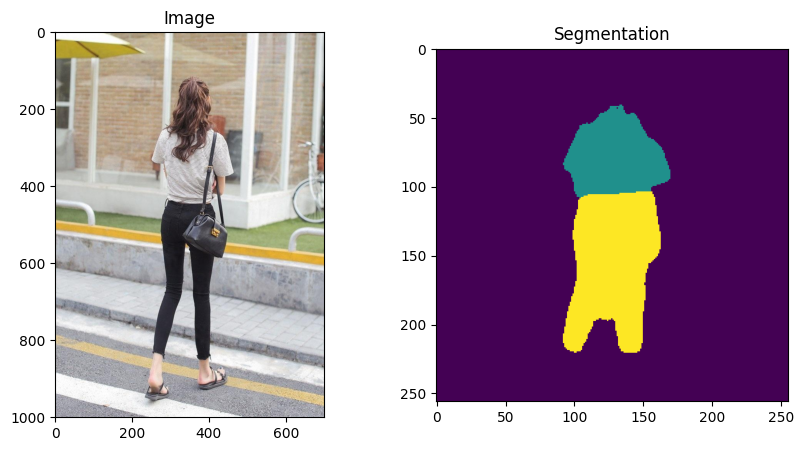

In [20]:
sample = train_data[0]

img = cv2.imread(sample["img_path"])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_input = torch.tensor(cv2.resize(img, (256, 256))).permute(2, 0, 1).float() / 255
img_input = img_input.unsqueeze(0).to(device)

with torch.no_grad():
    pred = model_transfer(img_input)

mask = torch.argmax(pred, dim=1).cpu().numpy()[0]

instances = extract_instances(mask)
print(instances)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(img);  plt.title("Image")
plt.subplot(1, 2, 2); plt.imshow(mask); plt.title("Segmentation")
plt.savefig("/kaggle/working/sample_prediction.png")

In [21]:
import os
print(os.listdir("/kaggle/working"))

['sample_prediction.png', 'Transfer_loss.png', '__notebook__.ipynb', 'Transfer.pth', 'Finetune.pth', 'Finetune_loss.png', 'Transfer_roc.png', 'Finetune_roc.png', 'label_map.json']
